In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
#3D GAUSSIAN DISTRIBUTION OF PARTICLES for each halo
L = 1.
Nhal = 300
Rad = 0.001
N = int(1e6)  # Number of particles per halo
Ncluster = int(0.7*N)
Nbackground = int(0.3*N)
Nparthal = int(Ncluster / Nhal)

# Generate non-overlapping halos
halos_x = []
halos_y = []
halos_z = []
for i in range(Nhal):
    x = np.random.uniform(0. + 4*Rad, L - 4*Rad)
    y = np.random.uniform(0. + 4*Rad, L - 4*Rad)
    z = np.random.uniform(0. + 4*Rad, L - 4*Rad)
    for x2,y2,z2 in zip(halos_x, halos_y, halos_z):
        while np.sqrt((x-x2)**2 + (y-y2)**2 + (z-z2)**2) < 4*Rad:
            x = np.random.uniform(0. + 4*Rad, L - 4*Rad)
            y = np.random.uniform(0. + 4*Rad, L - 4*Rad)
            z = np.random.uniform(0. + 4*Rad, L - 4*Rad)
    halos_x.append(x)
    halos_y.append(y)
    halos_z.append(z)

# Generate particles in halos
x = np.zeros(N)
y = np.zeros(N)
z = np.zeros(N)
for i in range(Nhal):
    x0 = halos_x[i]
    y0 = halos_y[i]
    z0 = halos_z[i]
    x[i*Nparthal:(i+1)*Nparthal] = np.random.normal(x0, Rad, Nparthal)
    y[i*Nparthal:(i+1)*Nparthal] = np.random.normal(y0, Rad, Nparthal)
    z[i*Nparthal:(i+1)*Nparthal] = np.random.normal(z0, Rad, Nparthal)


# Generate background particles
x[Ncluster:] = np.random.uniform(0. + 4*Rad, L - 4*Rad, Nbackground)
y[Ncluster:] = np.random.uniform(0. + 4*Rad, L - 4*Rad, Nbackground)
z[Ncluster:] = np.random.uniform(0. + 4*Rad, L - 4*Rad, Nbackground)

print('Number of particles: ', N)
print(len(x), len(y), len(z))
print(np.min(x), np.max(x))
print(np.min(y), np.max(y))
print(np.min(z), np.max(z))

print('interp. distance', 0.03*((L**3) / N)**(1/3))

Number of particles:  1000000
1000000 1000000 1000000
0.0 0.996176076755045
0.0 0.9983350040503514
0.0 0.9959999957279263
interp. distance 0.00030000000000000003


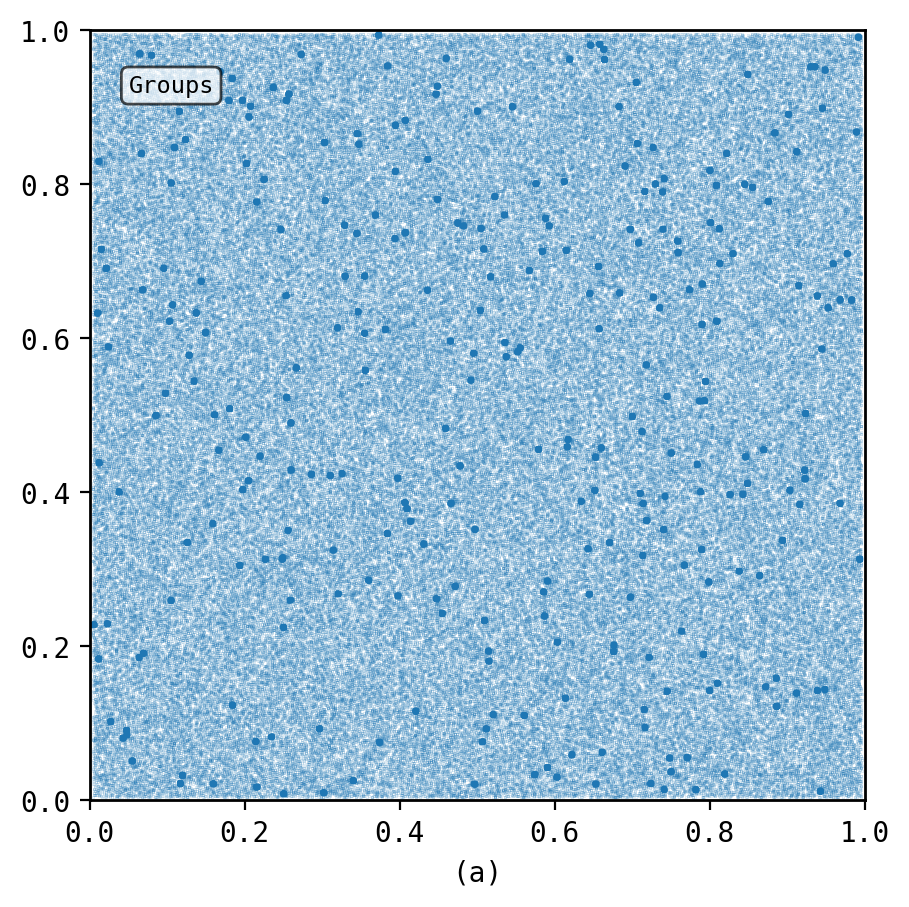

In [6]:
#plot

plt.rcParams["font.family"] = "monospace"
fontsize = 8.5
spines_width = 1.

fig, ax = plt.subplots(1, 1, figsize=(5,5), dpi = 200)
ax.scatter(x, y, s=0.01, marker='.', alpha=1,)
ax.set_xlabel('(a)')
ax.text(0.05, 0.92, 'Groups', transform=ax.transAxes, fontsize=fontsize,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black', alpha=0.7))


ax.set_xlim(0, L)
ax.set_ylim(0, L)

#set tihcker axis lines and grid
ax.spines['top'].set_linewidth(spines_width)
ax.spines['right'].set_linewidth(spines_width)
ax.spines['bottom'].set_linewidth(spines_width)
ax.spines['left'].set_linewidth(spines_width)


plt.savefig('fof_accelerated.png', bbox_inches='tight', pad_inches=0.1)

In [7]:
from scipy.io import FortranFile as FF

with FF('points.dat', 'w') as f:
    f.write_record(np.int32(N))
    f.write_record(x.astype(np.float32))
    f.write_record(y.astype(np.float32))
    f.write_record(z.astype(np.float32)) 

print(len(x), len(y), len(z))

1000000 1000000 1000000
